# Task 3 — GNN–BERT Fusion for Multi-Context Music Understanding

**Task:** Fuse GNN (segment-graph structure) + BERT (text/tag semantics) to
predict multi-label tags (genre + mood).

### Dataset choice: MagnaTagATune (MTAT)
- **Reliable access:** the canonical MTAT mirrors (mirg.city.ac.uk) are split into 3 zip parts and
  are often slow/flaky. This notebook instead pulls the dataset from a maintained **Hugging Face
  mirror** (`confit/magnatagatune`) that hosts a single `mp3.zip`, the tag annotation CSV, and the



## 1. Setup

In [ ]:
# Colab already ships torch; we only add what's missing.
!pip -q install huggingface_hub torch_geometric transformers librosa scikit-learn pandas tqdm --upgrade


In [ ]:
import os, json, random, math, warnings, zipfile
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch_geometric.data import Data, Batch
from torch_geometric.nn import SAGEConv, global_mean_pool
from transformers import DistilBertTokenizerFast, DistilBertModel

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---- Config (tune these; defaults are chosen to be GPU-light) ----
CFG = dict(
    N_CLIPS        = 4000,     # subsample of MTAT (raise once the pipeline is verified)
    SR             = 22050,
    N_MELS         = 128,
    N_CHROMA       = 12,
    SEG_SECONDS    = 5.0,      # fixed-window segmentation
    SIM_TAU        = 0.85,     # cosine-similarity threshold for extra graph edges
    MAX_TOK_LEN    = 32,       # short descriptor string -> short sequence is fine
    HIDDEN_DIM     = 128,
    BATCH_SIZE     = 16,
    EPOCHS         = 12,
    LR_GNN         = 1e-3,
    LR_BERT        = 2e-5,
    PATIENCE       = 3,
    DATA_HOME      = "/content/mtat_data",
    CACHE_DIR      = "/content/mtat_cache",
    CKPT_DIR       = "/content/checkpoints",
)
os.makedirs(CFG["DATA_HOME"], exist_ok=True)
os.makedirs(CFG["CACHE_DIR"], exist_ok=True)
os.makedirs(CFG["CKPT_DIR"], exist_ok=True)


Device: cuda


## 2. Dataset download (MagnaTagATune, official split)
Downloads 4 files once from the Hugging Face mirror `confit/magnatagatune`:
`annotations_final.csv` (tags), `train_gt_mtt.tsv` / `val_gt_mtt.tsv` / `test_gt_mtt.tsv`
(the standard clip-id splits), and `mp3.zip` (~3 GB of audio). `huggingface_hub` caches these
locally, so re-running this cell after a disconnect just verifies the cache instead of
re-downloading. If you already have MTAT audio in Google Drive, point `AUDIO_ROOT` at it directly
and skip the zip download/extraction.


In [ ]:
from huggingface_hub import hf_hub_download

REPO_ID = "confit/magnatagatune"

def hf_get(fname):
    return hf_hub_download(repo_id=REPO_ID, repo_type="dataset", filename=fname,
                            local_dir=CFG["DATA_HOME"])

annot_path = hf_get("annotations_final.csv")
train_tsv  = hf_get("train_gt_mtt.tsv")
val_tsv    = hf_get("val_gt_mtt.tsv")
test_tsv   = hf_get("test_gt_mtt.tsv")
mp3_zip    = hf_get("mp3.zip")   # ~3 GB, resumable + cached by huggingface_hub

AUDIO_ROOT = os.path.join(CFG["DATA_HOME"], "mp3_extracted")
if not os.path.exists(AUDIO_ROOT) or not os.listdir(AUDIO_ROOT):
    print("Extracting mp3.zip (one-time, a few minutes)...")
    with zipfile.ZipFile(mp3_zip) as zf:
        zf.extractall(AUDIO_ROOT)
print("Audio available under:", AUDIO_ROOT)

# Build a basename -> absolute-path index so we're robust to whatever internal
# folder layout the zip uses (avoids hardcoding a nested path assumption).
FILE_INDEX = {}
for root, _, files in os.walk(AUDIO_ROOT):
    for fn in files:
        if fn.lower().endswith(".mp3"):
            FILE_INDEX[fn] = os.path.join(root, fn)
print("Indexed", len(FILE_INDEX), "mp3 files")

def resolve_path(mp3_path):
    direct = os.path.join(AUDIO_ROOT, mp3_path)
    if os.path.exists(direct):
        return direct
    return FILE_INDEX.get(os.path.basename(mp3_path))


annotations_final.csv: reconstructing file:   0%|          |  0.00B / 21.5MB            

annotations_final.csv: downloading bytes:           |  0.00B            

train_gt_mtt.tsv:   0%|          | 0.00/4.80M [00:00<?, ?B/s]

val_gt_mtt.tsv:   0%|          | 0.00/469k [00:00<?, ?B/s]

test_gt_mtt.tsv:   0%|          | 0.00/1.37M [00:00<?, ?B/s]

mp3.zip: reconstructing file:   0%|          |  0.00B / 2.97GB            

mp3.zip: downloading bytes:           |  0.00B            

Extracting mp3.zip (one-time, a few minutes)...
Audio available under: /content/mtat_data/mp3_extracted
Indexed 25863 mp3 files


In [ ]:
# ---- Standard MTAT top-50 tag vocabulary (matches the literature benchmark) ----
TOP_TAGS = ['ambient','beat','beats','cello','choir','choral','classic','classical','country','dance',
            'drums','electronic','fast','female','female vocal','female voice','flute','guitar','harp',
            'harpsichord','indian','loud','male','male vocal','male voice','man','metal','new age',
            'no vocal','no vocals','no voice','opera','piano','pop','quiet','rock','singing','sitar',
            'slow','soft','solo','strings','synth','techno','violin','vocal','vocals','voice','weird','woman']
N_TAGS = len(TOP_TAGS)
TAG2IDX = {t: i for i, t in enumerate(TOP_TAGS)}

# Descriptor vocabulary: instrument/genre-ish tags used to build the *input text*.
# Kept disjoint from mood words so the text branch adds real signal rather than
# trivially encoding the mood labels it is also asked to predict.
MOOD_WORDS = {"slow", "fast", "quiet", "loud", "soft", "weird"}
DESCRIPTOR_TAGS = [t for t in TOP_TAGS if t not in MOOD_WORDS]

annot = pd.read_csv(annot_path, sep="\t")
annot = annot[annot[TOP_TAGS].sum(axis=1) > 0].reset_index(drop=True)   # keep clips with >=1 top-50 tag
ANNOT = annot.set_index("clip_id")
ID2PATH = ANNOT["mp3_path"].to_dict()
print("Usable clips (>=1 top-50 tag):", len(ANNOT))


Usable clips (>=1 top-50 tag): 21111


In [ ]:
# ---- Official standard split (clip-id lists shipped with the dataset) ----
def load_ids(tsv_path):
    ids_df = pd.read_csv(tsv_path, sep="\t", header=None)
    ids = ids_df[0].tolist()
    return [i for i in ids if i in ANNOT.index]

train_ids_full = load_ids(train_tsv)
val_ids_full   = load_ids(val_tsv)
test_ids_full  = load_ids(test_tsv)
random.shuffle(train_ids_full); random.shuffle(val_ids_full); random.shuffle(test_ids_full)

N_TRAIN = int(CFG["N_CLIPS"] * 0.8)
N_VAL   = int(CFG["N_CLIPS"] * 0.1)
N_TEST  = CFG["N_CLIPS"] - N_TRAIN - N_VAL

train_ids = train_ids_full[:N_TRAIN]
val_ids   = val_ids_full[:N_VAL]
test_ids  = test_ids_full[:N_TEST]
print("train/val/test clips:", len(train_ids), len(val_ids), len(test_ids))


train/val/test clips: 3200 400 400


## 3. Feature extraction + caching (audio -> mel/chroma -> segments)
Computed **once per clip** and cached as `.npz`. Re-running this cell after a crash skips
already-cached clips, so you never re-burn GPU/CPU time redoing preprocessing.


In [ ]:
import librosa

def segment_features(cid):
    cache_path = os.path.join(CFG["CACHE_DIR"], f"{cid}_feat.npz")
    if os.path.exists(cache_path):
        d = np.load(cache_path)
        return d["mel"], d["chroma"]

    mp3_path = resolve_path(ID2PATH[cid])
    y, sr = librosa.load(mp3_path, sr=CFG["SR"], mono=True)

    seg_len = int(CFG["SEG_SECONDS"] * sr)
    n_segs = max(1, len(y) // seg_len)
    mel_segs, chroma_segs = [], []
    for i in range(n_segs):
        chunk = y[i*seg_len:(i+1)*seg_len]
        if len(chunk) < seg_len // 2:
            continue
        mel = librosa.feature.melspectrogram(y=chunk, sr=sr, n_mels=CFG["N_MELS"])
        mel_db = librosa.power_to_db(mel, ref=np.max)
        chroma = librosa.feature.chroma_stft(y=chunk, sr=sr, n_chroma=CFG["N_CHROMA"])
        mel_segs.append(mel_db.mean(axis=1))       # (N_MELS,)
        chroma_segs.append(chroma.mean(axis=1))    # (N_CHROMA,)

    mel_arr = np.stack(mel_segs) if mel_segs else np.zeros((1, CFG["N_MELS"]), dtype=np.float32)
    chroma_arr = np.stack(chroma_segs) if chroma_segs else np.zeros((1, CFG["N_CHROMA"]), dtype=np.float32)
    np.savez(cache_path, mel=mel_arr.astype(np.float32), chroma=chroma_arr.astype(np.float32))
    return mel_arr, chroma_arr


def normalize(x):
    mu, sd = x.mean(0, keepdims=True), x.std(0, keepdims=True) + 1e-6
    return (x - mu) / sd


### 4. Graph construction (segment nodes, temporal + similarity edges)

In [ ]:
def build_graph(cid):
    graph_path = os.path.join(CFG["CACHE_DIR"], f"{cid}_graph.pt")
    if os.path.exists(graph_path):
        return torch.load(graph_path, weights_only=False)

    mel, chroma = segment_features(cid)
    mel_n, chroma_n = normalize(mel), normalize(chroma)
    node_feat = np.concatenate([mel_n, chroma_n], axis=1)  # (n_segs, N_MELS+N_CHROMA)
    n_segs = node_feat.shape[0]

    edges = set()
    # temporal adjacency
    for i in range(n_segs - 1):
        edges.add((i, i+1)); edges.add((i+1, i))
    # cosine-similarity edges (segment repetition / structure)
    if n_segs > 1:
        feat = torch.tensor(node_feat, dtype=torch.float32)
        feat_norm = F.normalize(feat, dim=1)
        sim = feat_norm @ feat_norm.T
        idx = (sim > CFG["SIM_TAU"]).nonzero(as_tuple=False)
        for a, b in idx.tolist():
            if a != b:
                edges.add((a, b))

    if not edges:
        edges = {(0, 0)}
    edge_index = torch.tensor(list(edges), dtype=torch.long).T

    x = torch.tensor(node_feat, dtype=torch.float32)
    data = Data(x=x, edge_index=edge_index)
    torch.save(data, graph_path)
    return data

### 5. Text branch: build pseudo-caption + label, tokenize

In [ ]:
TOKENIZER = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def build_label(cid):
    return ANNOT.loc[cid, TOP_TAGS].values.astype(np.float32)

def build_caption(cid):
    pos_tags = [t for t in TOP_TAGS if ANNOT.loc[cid, t] == 1]
    desc = [t for t in pos_tags if t in DESCRIPTOR_TAGS]
    if not desc:
        desc = pos_tags if pos_tags else ["music"]
    return "a song that sounds like " + ", ".join(sorted(set(desc))[:6])


### 6. PyTorch Dataset + collate (graph + text + label)

In [ ]:
class MTATFusionDataset(Dataset):
    def __init__(self, ids):
        self.ids = ids

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        cid = self.ids[idx]
        graph = build_graph(cid)
        caption = build_caption(cid)
        label = torch.tensor(build_label(cid))
        return graph, caption, label


def collate_fn(batch):
    graphs, captions, labels = zip(*batch)
    graph_batch = Batch.from_data_list(list(graphs))
    tok = TOKENIZER(list(captions), padding=True, truncation=True,
                     max_length=CFG["MAX_TOK_LEN"], return_tensors="pt")
    labels = torch.stack(labels)
    return graph_batch, tok, labels


In [ ]:
from torch.utils.data import DataLoader

train_ds = MTATFusionDataset(train_ids)
val_ds   = MTATFusionDataset(val_ids)
test_ds  = MTATFusionDataset(test_ids)

train_loader = DataLoader(train_ds, batch_size=CFG["BATCH_SIZE"], shuffle=True,  collate_fn=collate_fn, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=CFG["BATCH_SIZE"], shuffle=False, collate_fn=collate_fn, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=CFG["BATCH_SIZE"], shuffle=False, collate_fn=collate_fn, num_workers=2)


## 7. Model — GNN encoder, BERT encoder, cross-attention fusion
`mode` lets us reuse the exact same class for the **ablation study** required by Task 3:
`bert_only`, `gnn_only`, `concat` (early fusion), `cross_attn` (recommended, spec-matching).


In [ ]:
NODE_IN_DIM = CFG["N_MELS"] + CFG["N_CHROMA"]

class GNNEncoder(nn.Module):
    def __init__(self, in_dim, hid):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hid)
        self.conv2 = SAGEConv(hid, hid)

    def forward(self, x, edge_index, batch):
        h = F.relu(self.conv1(x, edge_index))
        h = F.relu(self.conv2(h, edge_index))
        node_h = h
        g = global_mean_pool(h, batch)   # graph-level readout
        return g, node_h


class TextEncoder(nn.Module):
    def __init__(self, hid, freeze_all_but_last=True):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        if freeze_all_but_last:
            for p in self.bert.parameters():
                p.requires_grad = False
            for p in self.bert.transformer.layer[-1].parameters():
                p.requires_grad = True
        self.proj = nn.Linear(self.bert.config.dim, hid)

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        out = self.proj(out)             # (B, L, hid)
        cls = out[:, 0, :]                # CLS-like (first token) pooled vector
        return cls, out, attention_mask


class CrossAttention(nn.Module):
    # A = softmax(QK^T / sqrt(d));  z = concat(g, A H_text)
    def __init__(self, hid):
        super().__init__()
        self.Wq = nn.Linear(hid, hid)
        self.Wk = nn.Linear(hid, hid)
        self.Wv = nn.Linear(hid, hid)
        self.scale = hid ** 0.5

    def forward(self, g, H_text, text_mask):
        Q = self.Wq(g).unsqueeze(1)                 # (B,1,hid)
        K = self.Wk(H_text)                          # (B,L,hid)
        V = self.Wv(H_text)                          # (B,L,hid)
        scores = (Q @ K.transpose(1, 2)) / self.scale  # (B,1,L)
        mask = (1.0 - text_mask.unsqueeze(1).float()) * -1e9
        scores = scores + mask
        attn = F.softmax(scores, dim=-1)             # (B,1,L)
        context = (attn @ V).squeeze(1)              # (B,hid)
        return context, attn.squeeze(1)


class GNNBERTFusion(nn.Module):
    def __init__(self, hid=CFG["HIDDEN_DIM"], n_tags=N_TAGS, mode="cross_attn"):
        super().__init__()
        self.mode = mode
        self.gnn = GNNEncoder(NODE_IN_DIM, hid)
        self.text = TextEncoder(hid)
        self.cross_attn = CrossAttention(hid)

        if mode in ("bert_only", "gnn_only"):
            in_dim = hid
        else:  # concat or cross_attn
            in_dim = hid * 2

        self.head = nn.Sequential(
            nn.Linear(in_dim, hid), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(hid, n_tags)
        )

    def forward(self, graph_batch, tok):
        g, _ = self.gnn(graph_batch.x, graph_batch.edge_index, graph_batch.batch)
        t_cls, H_text, mask = self.text(tok["input_ids"], tok["attention_mask"])

        attn_weights = None
        if self.mode == "bert_only":
            z = t_cls
        elif self.mode == "gnn_only":
            z = g
        elif self.mode == "concat":
            z = torch.cat([g, t_cls], dim=-1)
        else:  # cross_attn (spec: z = concat(g, A H_text))
            context, attn_weights = self.cross_attn(g, H_text, mask)
            z = torch.cat([g, context], dim=-1)

        logits = self.head(z)
        return logits, attn_weights


## 8. Training loop (AMP, differential LR, early stopping)

In [ ]:
from sklearn.metrics import f1_score, average_precision_score

def evaluate(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad(), torch.cuda.amp.autocast():
        for graph_batch, tok, labels in loader:
            graph_batch = graph_batch.to(DEVICE)
            tok = {k: v.to(DEVICE) for k, v in tok.items()}
            logits, _ = model(graph_batch, tok)
            all_logits.append(logits.float().cpu())
            all_labels.append(labels)
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs > 0.5).astype(int)

    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)
    micro_f1 = f1_score(labels, preds, average="micro", zero_division=0)
    aucprs = []
    for k in range(labels.shape[1]):
        if labels[:, k].sum() > 0:
            aucprs.append(average_precision_score(labels[:, k], probs[:, k]))
    auc_pr = float(np.mean(aucprs)) if aucprs else 0.0
    return macro_f1, micro_f1, auc_pr


def train_model(mode="cross_attn", tag=""):
    model = GNNBERTFusion(mode=mode).to(DEVICE)
    bert_params = [p for p in model.text.bert.parameters() if p.requires_grad]
    other_params = [p for n, p in model.named_parameters() if "text.bert" not in n]
    optim = torch.optim.AdamW([
        {"params": bert_params, "lr": CFG["LR_BERT"]},
        {"params": other_params, "lr": CFG["LR_GNN"]},
    ])
    scaler = torch.cuda.amp.GradScaler()
    bce = nn.BCEWithLogitsLoss()

    best_f1, patience_left = -1, CFG["PATIENCE"]
    ckpt_path = os.path.join(CFG["CKPT_DIR"], f"best_{mode}{tag}.pt")

    for epoch in range(1, CFG["EPOCHS"] + 1):
        model.train()
        total_loss = 0.0
        for graph_batch, tok, labels in train_loader:
            graph_batch = graph_batch.to(DEVICE)
            tok = {k: v.to(DEVICE) for k, v in tok.items()}
            labels = labels.to(DEVICE)

            optim.zero_grad()
            with torch.cuda.amp.autocast():
                logits, _ = model(graph_batch, tok)
                loss = bce(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optim)
            scaler.update()
            total_loss += loss.item()

        val_f1, val_micro, val_aucpr = evaluate(model, val_loader)
        print(f"[{mode}] epoch {epoch:02d} | loss {total_loss/len(train_loader):.4f} "
              f"| val Macro-F1 {val_f1:.4f} | val AUC-PR {val_aucpr:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            patience_left = CFG["PATIENCE"]
            torch.save(model.state_dict(), ckpt_path)
        else:
            patience_left -= 1
            if patience_left == 0:
                print("Early stopping.")
                break

    model.load_state_dict(torch.load(ckpt_path))
    return model


## 9. Ablation study (Task 3 deliverable): BERT-only, GNN-only, early-concat, cross-attention

In [ ]:
results = {}
for mode in ["bert_only", "gnn_only", "concat", "cross_attn"]:
    print("\n=== Training mode:", mode, "===")
    model = train_model(mode=mode)
    test_f1, test_micro, test_aucpr = evaluate(model, test_loader)
    results[mode] = dict(macro_f1=test_f1, micro_f1=test_micro, auc_pr=test_aucpr)
    print(f"[{mode}] TEST Macro-F1 {test_f1:.4f} | Micro-F1 {test_micro:.4f} | AUC-PR {test_aucpr:.4f}")

results_df = pd.DataFrame(results).T
print(results_df)
results_df.to_csv(os.path.join(CFG["CKPT_DIR"], "ablation_results.csv"))



=== Training mode: bert_only ===


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[bert_only] epoch 01 | loss 0.2080 | val Macro-F1 0.3335 | val AUC-PR 0.6260
[bert_only] epoch 02 | loss 0.1016 | val Macro-F1 0.6092 | val AUC-PR 0.7585
[bert_only] epoch 03 | loss 0.0765 | val Macro-F1 0.6791 | val AUC-PR 0.8084
[bert_only] epoch 04 | loss 0.0639 | val Macro-F1 0.7569 | val AUC-PR 0.8430
[bert_only] epoch 05 | loss 0.0566 | val Macro-F1 0.8055 | val AUC-PR 0.8711
[bert_only] epoch 06 | loss 0.0511 | val Macro-F1 0.8027 | val AUC-PR 0.8782
[bert_only] epoch 07 | loss 0.0472 | val Macro-F1 0.8324 | val AUC-PR 0.8856
[bert_only] epoch 08 | loss 0.0456 | val Macro-F1 0.8400 | val AUC-PR 0.8893
[bert_only] epoch 09 | loss 0.0436 | val Macro-F1 0.8288 | val AUC-PR 0.8896
[bert_only] epoch 10 | loss 0.0423 | val Macro-F1 0.8523 | val AUC-PR 0.8910
[bert_only] epoch 11 | loss 0.0409 | val Macro-F1 0.8384 | val AUC-PR 0.8939
[bert_only] epoch 12 | loss 0.0399 | val Macro-F1 0.8612 | val AUC-PR 0.8973
[bert_only] TEST Macro-F1 0.8704 | Micro-F1 0.8896 | AUC-PR 0.9082

=== Trai

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[concat] epoch 01 | loss 0.2115 | val Macro-F1 0.2926 | val AUC-PR 0.5584
[concat] epoch 02 | loss 0.1057 | val Macro-F1 0.5626 | val AUC-PR 0.7420
[concat] epoch 03 | loss 0.0790 | val Macro-F1 0.6825 | val AUC-PR 0.8090
[concat] epoch 04 | loss 0.0651 | val Macro-F1 0.7414 | val AUC-PR 0.8419
[concat] epoch 05 | loss 0.0565 | val Macro-F1 0.8018 | val AUC-PR 0.8702
[concat] epoch 06 | loss 0.0511 | val Macro-F1 0.8151 | val AUC-PR 0.8741
[concat] epoch 07 | loss 0.0480 | val Macro-F1 0.8375 | val AUC-PR 0.8826
[concat] epoch 08 | loss 0.0458 | val Macro-F1 0.8426 | val AUC-PR 0.8852
[concat] epoch 09 | loss 0.0436 | val Macro-F1 0.8353 | val AUC-PR 0.8885
[concat] epoch 10 | loss 0.0419 | val Macro-F1 0.8488 | val AUC-PR 0.8916
[concat] epoch 11 | loss 0.0409 | val Macro-F1 0.8482 | val AUC-PR 0.8902
[concat] epoch 12 | loss 0.0391 | val Macro-F1 0.8675 | val AUC-PR 0.8941
[concat] TEST Macro-F1 0.8570 | Micro-F1 0.8808 | AUC-PR 0.9095

=== Training mode: cross_attn ===


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[cross_attn] epoch 01 | loss 0.2256 | val Macro-F1 0.2008 | val AUC-PR 0.4805
[cross_attn] epoch 02 | loss 0.1176 | val Macro-F1 0.5273 | val AUC-PR 0.7142
[cross_attn] epoch 03 | loss 0.0875 | val Macro-F1 0.6295 | val AUC-PR 0.7598
[cross_attn] epoch 04 | loss 0.0739 | val Macro-F1 0.6834 | val AUC-PR 0.7938
[cross_attn] epoch 05 | loss 0.0650 | val Macro-F1 0.6997 | val AUC-PR 0.8261
[cross_attn] epoch 06 | loss 0.0585 | val Macro-F1 0.7715 | val AUC-PR 0.8448
[cross_attn] epoch 07 | loss 0.0528 | val Macro-F1 0.7855 | val AUC-PR 0.8604
[cross_attn] epoch 08 | loss 0.0490 | val Macro-F1 0.7923 | val AUC-PR 0.8696
[cross_attn] epoch 09 | loss 0.0466 | val Macro-F1 0.8264 | val AUC-PR 0.8757
[cross_attn] epoch 10 | loss 0.0451 | val Macro-F1 0.8306 | val AUC-PR 0.8770
[cross_attn] epoch 11 | loss 0.0429 | val Macro-F1 0.8411 | val AUC-PR 0.8795
[cross_attn] epoch 12 | loss 0.0413 | val Macro-F1 0.8283 | val AUC-PR 0.8814
[cross_attn] TEST Macro-F1 0.8410 | Micro-F1 0.8782 | AUC-PR 0.8

## 10. t-SNE of fused embeddings (colored by top tag)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


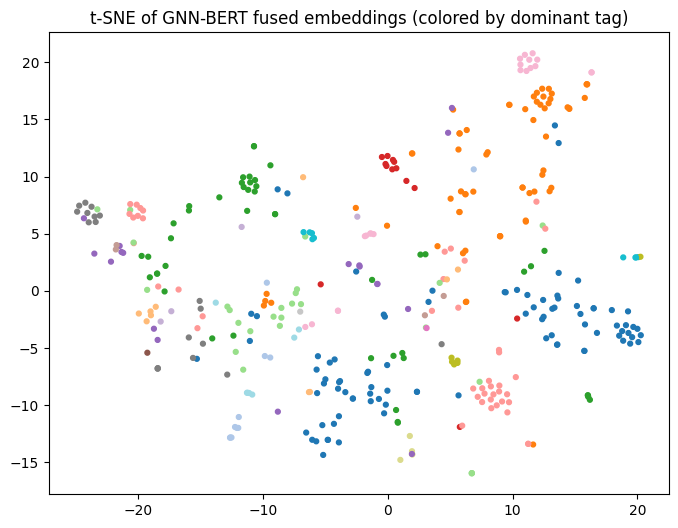

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

best_model = GNNBERTFusion(mode="cross_attn").to(DEVICE)
best_model.load_state_dict(torch.load(os.path.join(CFG["CKPT_DIR"], "best_cross_attn.pt")))
best_model.eval()

embeds, top_tag_ids = [], []
with torch.no_grad(), torch.cuda.amp.autocast():
    for graph_batch, tok, labels in test_loader:
        graph_batch = graph_batch.to(DEVICE)
        tok = {k: v.to(DEVICE) for k, v in tok.items()}
        g, _ = best_model.gnn(graph_batch.x, graph_batch.edge_index, graph_batch.batch)
        t_cls, H_text, mask = best_model.text(tok["input_ids"], tok["attention_mask"])
        context, _ = best_model.cross_attn(g, H_text, mask)
        z = torch.cat([g, context], dim=-1)
        embeds.append(z.float().cpu().numpy())
        top_tag_ids.append(labels.argmax(dim=1).numpy())

embeds = np.concatenate(embeds)
top_tag_ids = np.concatenate(top_tag_ids)

tsne = TSNE(n_components=2, random_state=SEED, init="pca", perplexity=30)
proj = tsne.fit_transform(embeds)

plt.figure(figsize=(8, 6))
plt.scatter(proj[:, 0], proj[:, 1], c=top_tag_ids, cmap="tab20", s=12)
plt.title("t-SNE of GNN-BERT fused embeddings (colored by dominant tag)")
plt.savefig(os.path.join(CFG["CKPT_DIR"], "tsne_fusion.png"), dpi=150)
plt.show()


## 11. Case studies — graph structure + caption alignment (3 examples)

In [ ]:
def show_case_study(cid):
    graph = build_graph(cid).to(DEVICE)
    caption = build_caption(cid)
    label = torch.tensor(build_label(cid)).unsqueeze(0)
    graph_batch = Batch.from_data_list([graph]).to(DEVICE)
    tok = TOKENIZER([caption], padding=True, truncation=True,
                     max_length=CFG["MAX_TOK_LEN"], return_tensors="pt")
    tok = {k: v.to(DEVICE) for k, v in tok.items()}

    with torch.no_grad(), torch.cuda.amp.autocast():
        logits, attn = best_model(graph_batch, tok)
    probs = torch.sigmoid(logits.float()).cpu().numpy()[0]
    pred_tags = [TOP_TAGS[i] for i in np.argsort(-probs)[:5]]
    true_tags = [TOP_TAGS[i] for i in range(N_TAGS) if label[0, i] == 1]

    tokens = TOKENIZER.convert_ids_to_tokens(tok["input_ids"][0].cpu())
    print(f"Clip id: {cid}")
    print(f"  Caption (input text): \"{caption}\"")
    print(f"  Graph: {graph.x.shape[0]} segments, {graph.edge_index.shape[1]} edges")
    print(f"  True tags : {true_tags}")
    print(f"  Top-5 predicted tags: {pred_tags}")
    if attn is not None:
        w = attn[0].cpu().numpy()
        top_tok_idx = np.argsort(-w)[:5]
        print("  Cross-attention focus (token: weight):",
              [(tokens[i], round(float(w[i]), 3)) for i in top_tok_idx])
    print("-" * 60)

for cid in test_ids[:3]:
    show_case_study(cid)


Clip id: 20616
  Caption (input text): "a song that sounds like no vocal, no vocals"
  Graph: 5 segments, 8 edges
  True tags : ['no vocal', 'no vocals']
  Top-5 predicted tags: ['no vocal', 'no vocals', 'slow', 'loud', 'fast']
  Cross-attention focus (token: weight): [('vocal', 0.31), (',', 0.213), ('vocals', 0.187), ('no', 0.106), ('no', 0.099)]
------------------------------------------------------------
Clip id: 35482
  Caption (input text): "a song that sounds like classical, piano, techno"
  Graph: 5 segments, 8 edges
  True tags : ['classical', 'piano', 'techno']
  Top-5 predicted tags: ['piano', 'classical', 'slow', 'fast', 'ambient']
  Cross-attention focus (token: weight): [('piano', 0.253), ('classical', 0.191), ('techno', 0.132), (',', 0.103), (',', 0.095)]
------------------------------------------------------------
Clip id: 12835
  Caption (input text): "a song that sounds like piano"
  Graph: 5 segments, 8 edges
  True tags : ['piano']
  Top-5 predicted tags: ['piano', '

## 12. Notes / how to scale up safely

- All checkpoints and the ablation CSV are saved under `CFG["CKPT_DIR"]`; copy that folder (and
  optionally `CFG["DATA_HOME"]`, so you never re-download the 3 GB archive) to Google Drive at the
  end of the session:
```python
from google.colab import drive
drive.mount('/content/drive')
!cp -r /content/checkpoints /content/drive/MyDrive/gnn_bert_task3_ckpts
!cp -r /content/mtat_data /content/drive/MyDrive/mtat_data_cache   # optional, saves the 3GB re-download next time
```
